In [10]:
# --- repo bootstrap: make `panelclv` importable and relative data paths resolve ---
import os, sys
from pathlib import Path
_root = Path.cwd().resolve()
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
os.chdir(_root)                                 # so "Datasets/..." resolve from repo root
_src = _root / 'src'
if _src.exists() and str(_src) not in sys.path:  # fallback if panelclv isn't pip-installed
    sys.path.insert(0, str(_src))
# ---------------------------------------------------------------------------------

%reload_ext autoreload
%autoreload 2

In Terminal all the time
cd ~/Desktop/Thesis
source venvs/thesis_rocm/bin/activate

cd /home/virthian/Desktop/Thesis/Package/my_package/autoseqmodels
pip install -e .

In [11]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import json
from pathlib import Path

# ---------------------------------------------------------------------------
# Third-party
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------------------------
# This project (installed via `pip install -e .`, so no manual path setup).
# Models/__init__.py is the public API.
# ---------------------------------------------------------------------------
from panelclv.data_preparation import dynamic_panel_dataset
from panelclv.models import (
    MultinomialLSTMModel,  # softmax-over-counts LSTM (classifier head)
    compute_class_weights,  # class weights for weighted_ce / focal
    InferenceMultinomialLSTMModel,  # same backbone, sampling head
    mc_forecast,  # Valendin-style autoregressive holdout rollout
    mc_compute_metrics,  # RMSE / bias% / aggregate-MAPE
)
from panelclv.training import (
    fit_model,  # shared training loop (CE / weighted_ce / focal / emd)
)
from panelclv.tuning import (
    run_optuna_study,  # hyper-parameter + covariate search
)
from panelclv.evaluation import (
    weekly_actuals,
    weekly_aggregate_predictions,
    plot_weekly_aggregated,
    metrics_table,
    alignment_check,
    save_predictions_to_csv,
)
from panelclv.experiments import (
    make_data_builder,  # builds the Optuna data_builder closure
    build_inference_from_trial,  # rebuilds the winning model + loads its checkpoint
    refit_best_trial,  # warm-start retrain the winner on the full calibration window
)

# Data Loading


### Panels configuration

In [12]:
from panelclv.configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    # Temporal validation window: the last year of calibration (2000) is held out
    # for early stopping / model selection -- a TIME window over all customers,
    # never trained on. ~52 weeks, matching the holdout length.
    validation_start="2000-01-01",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "week"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_week_sin_cos": True},
    ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # week_sin / week_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=("year_idx", "high.season"),
    static=("Gender", "Income"),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto", "Gender": "auto", "Income": "auto"},
)


In [4]:
from panelclv.configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronicV2_customer_month_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="monthly",
    training_start="1999-01-01", training_end="2000-12-31",
    # Temporal validation window: the last year of calibration (2000) is held out
    # for early stopping / model selection -- a TIME window over all customers,
    # never trained on. ~52 weeks, matching the holdout length.
    validation_start="2000-01-01",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "month"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_month_sin_cos": True},
    #ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # month_sin / month_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=("year_idx", "high.season"),
    static=("Gender", "Income"),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto", "Gender": "auto", "Income": "auto"},
)


In [ ]:
# ---- Monte Carlo forecast settings ----------------------------------------
# Single source of truth for the holdout simulation count: every mc_forecast
# call below uses N_SIMULATIONS, so all models are compared on equal footing.
# Higher -> smoother per-customer mean, more compute. MC_SEED makes the
# forecast reproducible (same model + data + seed -> identical sampled paths).


In [ ]:
# ---- 1. Build the (N, T, F) arrays from your config ----------------------
# prepare_dataset slices the calibration/holdout windows, engineers the time +
# AR features, and reshapes everything into the model-ready `data` dict
# (calibration, holdout, samples, targets, seq_cols, input_spec, ids, ...).
#
# The train/validation split is TEMPORAL and lives in the config: `validation_start`
# cuts the calibration window so weights train on [training_start, validation_start)
# and the tail [validation_start, training_end] is the validation window (all
# customers, never trained on). prepare_dataset records it as data_full["val_start_idx"];
# make_loaders / make_data_builder build the loaders from it -- no customer-wise split.
panel     = pd.read_csv(csv_path)
data_full = dynamic_panel_dataset.prepare_dataset(panel, cfg)


## LSTM training & hyperparameter search

### LSTM with Optuna

### Loss trials

In [ ]:
# ---- 5. (Optional) class weights for focal / weighted_ce -----------------
# Only used by loss_type='weighted_ce' / 'focal'; for the paper-faithful
# 'cross_entropy' run the weights are computed but ignored downstream.
LOSS_TYPE     = "cross_entropy"            # 'cross_entropy' | 'weighted_ce' | 'focal' | 'emd'

# Pass the data dict straight in: compute_class_weights reads the labels from
# data_full["targets"] and infers num_classes (= max_trans) from the resolved
# target embedding. With the temporal split it weights on the TRAINING PREFIX only
# (periods before validation_start), so the held-out window never leaks into the
# loss. Inverse-frequency weights, normalised to mean 1.
# NOTE: on this sparse panel the zero class is overwhelmingly common, so
# weighted_ce / focal tilt the distribution toward the rare large counts and
# tend to OVER-predict -- keep cross_entropy unless diagnostics say otherwise.
class_weights = compute_class_weights(data_full)
print("class_weights:", class_weights.tolist())


In [16]:
# ---- 6. data_builder for Optuna -----------------------------------------
# `make_data_builder` returns the closure run_optuna_study calls each trial: it
# slices data_full to the trial's feature subset and builds the temporal train/val
# DataLoaders (the split is data_full["val_start_idx"], shared by every trial).
data_builder = make_data_builder(data_full)


## Optuna optimization cross entropy

In [ ]:
# ---- 7. Run the LSTM Optuna study ---------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"lstm_{LOSS_TYPE}"            # one study per loss → no schema collisions

lstm_study = run_optuna_study(
    model_type="lstm",
    data_builder=data_builder,
    data_info={
        "n_epochs":       150,
        "patience":       7,
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        "class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("month_sin", "month_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=200,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/aug_lstm_pareto.db", #new line
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-05-31 21:54:27,205] A new study created in RDB with name: lstm_cross_entropy_20260531_2154
[W 2026-05-31 21:55:00,717] Trial 0 failed with parameters: {'hidden_dim': 128, 'memory_units': 32, 'dense_units': 64, 'dropout': 0.2832290311184182, 'learning_rate': 0.00010725209743172001, 'weight_decay': 0.00757947995334801, 'batch_size': 64, 'use_Gender': False, 'use_Income': True, 'use_high.season': False, 'use_year_idx': False, 'use_week_sin+week_cos': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/virthian/Desktop/Thesis/Package_Notebook_refactored/Models/optuna_tuning.py", line 762, in <lambda>
    lambda trial: objective(
                  ^^^^^^^^^^
  File "/home/virthian/Desktop/Thesis/Package_Notebook_refactored/Mo

KeyboardInterrupt: 

### Optuna with rollout

In [ ]:
# ---- 7. Run the LSTM Optuna study ---------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"lstm_{LOSS_TYPE}_rollout_composite"            # one study per loss → no schema collisions

lstm_study = run_optuna_study(
    model_type="lstm",
    selection_metric="rollout_composite",  # new line: optimize the metric we actually care about, not just val loss
    rollout_data=data_full,                        # new line: pass the full data for the rollout metric; the study will split it internally
    rollout_n_simulations=100,
    data_builder=data_builder,
    data_info={
        "n_epochs":       150,
        "patience":       7,
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        "class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=20,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/aug_lstm_pareto.db", #new line
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-06-01 16:51:06,135] A new study created in RDB with name: lstm_cross_entropy_rollout_composite_20260601_1651
[I 2026-06-01 16:52:03,940] Trial 0 finished with value: 1.6120050353219442 and parameters: {'hidden_dim': 128, 'memory_units': 32, 'dense_units': 64, 'dropout': 0.2832290311184182, 'learning_rate': 0.00010725209743172001, 'weight_decay': 0.00757947995334801, 'batch_size': 64, 'use_Gender': False, 'use_Income': True, 'use_high.season': False, 'use_year_idx': False, 'use_week_sin+week_cos': False}. Best is trial 0 with value: 1.6120050353219442.
[I 2026-06-01 16:52:25,397] Trial 1 finished with value: 1.4146070887810915 and parameters: {'hidden_dim': 64, 'memory_units': 128, 'dense_units': 128, 'dropout': 0.38625281322982374, 'learning_rate': 0.0015635108708133452, 'weight_decay': 1.6536937182824424e-05, 'batch_size': 128, 'use_Gender': False, 'use_Income': False, 'use_high.season': False, 'use_year_idx': False, 'use_week_sin+week_cos': True}. Best is trial 1 with value: 

best trial   : 3
best val loss: 1.31058395945147
best params  : {'hidden_dim': 128, 'memory_units': 128, 'dense_units': 32, 'dropout': 0.12439292868626489, 'learning_rate': 0.0003022283475646735, 'weight_decay': 0.000828752236376816, 'batch_size': 128, 'use_Gender': False, 'use_Income': True, 'use_high.season': True, 'use_year_idx': True, 'use_week_sin+week_cos': False}
checkpoint   : checkpoints/lstm_optuna/lstm_cross_entropy_rollout_composite_20260601_1651/lstm_trial_3.pth


### Optuna rollout but with less CE discrimination (Long to compute)

In [ ]:
# ---- 7. Run the LSTM Optuna study ---------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"lstm_{LOSS_TYPE}_rollout_composite_NO_CE"            # one study per loss → no schema collisions
import optuna
lstm_study = run_optuna_study(
    model_type="lstm",
    selection_metric="rollout_composite",  # new line: optimize the metric we actually care about, not just val loss
    rollout_data=data_full,                        # new line: pass the full data for the rollout metric; the study will split it internally
    pruner=optuna.pruners.NoPruner(),  # remove pruning
    rollout_n_simulations=200,
    data_builder=data_builder,
    data_info={
        "n_epochs":       150,
        "patience":       7,
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        "class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=20,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/aug_lstm_pareto.db", #new line
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

In [18]:
# ---- 8. Rebuild the LSTM with the Optuna-selected arch + load weights ----
# `build_inference_from_trial` reads the best trial's architecture + checkpoint,
# slices data_full to that trial's feature subset, rebuilds the matching inference
# model (mode="sample"), and loads the weights. It returns BOTH the model and the
# sliced `data_best` -- feed data_best (not data_full) to the forecaster so the
# feature columns match the trained weights.
inference_model, data_best = build_inference_from_trial(lstm_study, data_full, "lstm")

In [ ]:
# ---- 8b. (Optional) Final retrain on the FULL calibration window ----------
# Valendin et al. (the paper) warm-start the selected model and fine-tune it for a
# few BIG-BATCH epochs on the FULL calibration window -- the temporal validation tail
# INCLUDED -- so the weights also LEARN the most recent periods, not just condition on
# them at forecast time (warm-up always sees the full calibration regardless). This
# rebinds inference_model / data_best with the refit weights.
#
# Tune the retrain here:
REFIT_ON_FULL_CALIBRATION = True   # False -> forecast with the tuning checkpoint as-is
                                   #          (the published rfm2lstm GitHub behaviour)
REFIT_BATCH_SIZE = 512             # the paper's "big batch"; raise/lower to taste
REFIT_N_EPOCHS   = None            # None -> a few epochs (default 5); set an int
                                   #         for a fixed number of epochs

if REFIT_ON_FULL_CALIBRATION:
    inference_model, data_best = refit_best_trial(
        lstm_study, data_full, "lstm",
        n_epochs=REFIT_N_EPOCHS,
        batch_size=REFIT_BATCH_SIZE,
        device=device,
        checkpoint_dir="./checkpoints/lstm_optuna",
    )


In [ ]:
# ---- 9. Valendin-style autoregressive MC forecast ------------------------
# mc_forecast warms the model on each customer's full calibration window, then
# steps through the holdout one period at a time: at every step it SAMPLES a
# count class from the softmax and feeds that sample back as the next input
# (true holdout targets are never seen). Averaging n_simulations such paths
# gives the expected count per customer per week. AR features are recomputed
# from the sampled history inside the rollout, so nothing leaks.
N_SIMULATIONS = 600          # more paths -> smoother mean, more compute
MC_SEED = 42                 # fixes the sampling so the forecast is reproducible
forecast = mc_forecast(
    inference_model,
    data_best,               # the SLICED dict (matches the trained feature set)
    n_simulations=N_SIMULATIONS,
    device=device,
    seed=MC_SEED,
)

# Guard against a stale (not-re-run) cell silently reporting an old count.
assert forecast["simulations"].shape[0] == forecast["n_simulations"] == N_SIMULATIONS

# simulations = the raw sampled paths; prediction_mean = their mean (the point
# forecast); actual = the true holdout counts, pulled from data_best["holdout"].
print("simulations shape:", forecast["simulations"].shape)        # (S, N, T_HOLD)
print("prediction mean  :", forecast["prediction_mean"].shape)    # (N, T_HOLD)
print("actual (real)    :", forecast["actual"].shape)             # (N, T_HOLD)


In [ ]:
# ---- 10. Score + sanity check -------------------------------------------
# mc_compute_metrics works on the per-customer (N, T_HOLD) arrays and returns
# the thesis headline metrics: RMSE, aggregate bias %, and aggregate-style MAPE.
metrics = mc_compute_metrics(forecast["actual"], forecast["prediction_mean"])
print(metrics)

# Eyeball the weekly aggregate (sum over customers) for the first 20 weeks: a
# quick read on whether the forecast tracks the level and the seasonal shape
# before drawing the full plot. Persistent pred > actual here = positive bias.
agg_pred   = forecast["prediction_mean"].sum(axis=0)              # (T_HOLD,)
agg_actual = forecast["actual"].sum(axis=0)
for i in range(min(20, len(agg_pred))):
    print(f"  week {i:>2}  pred={agg_pred[i]:6.1f}  actual={agg_actual[i]:6.1f}")


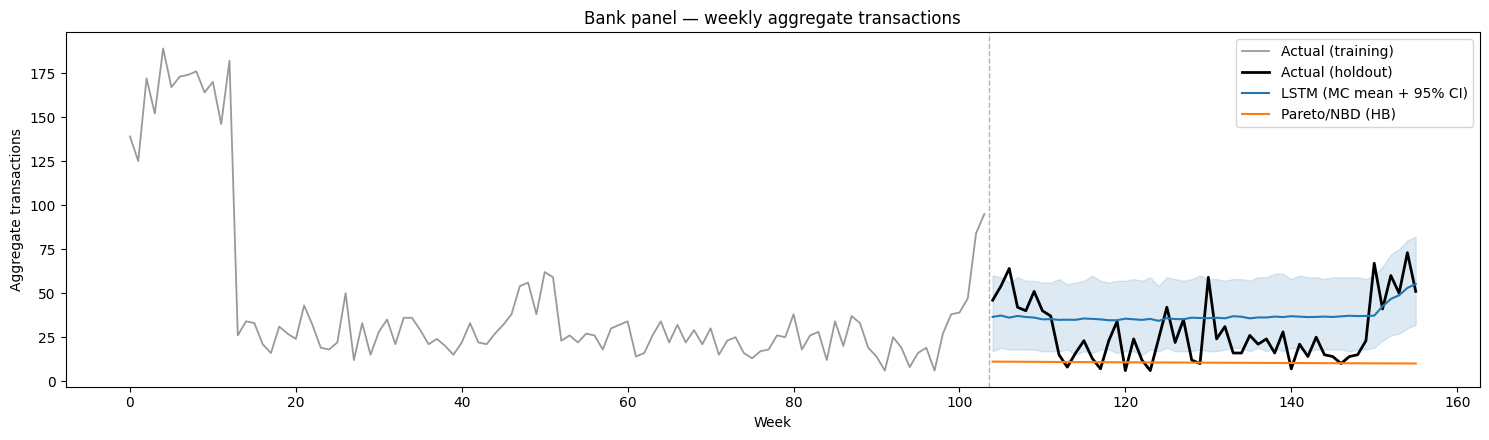

In [24]:
# Aggregate actuals across customers per holdout week.
actuals = forecast["actual"].sum(axis=0)            # (T_HOLD,)

# (Optional) training-window aggregate to show context to the left of the holdout.
# data_full["calibration"] is (N, T_CAL, F); the target column lives at target_idx.
target_idx    = data_full["seq_cols"].index(data_full["target_col"])
train_actuals = data_full["calibration"][..., target_idx].sum(axis=0)   # (T_CAL,)

# Add a trailing 1-axis so weekly_aggregate_predictions takes the (S, N, T, 1)
# branch and draws the 95% MC ribbon.
mc_sims = forecast["simulations"][..., None]        # (S, N, T_HOLD, 1)

fig, ax = plot_weekly_aggregated(
				actuals=actuals,
    data=data_best,
    pareto_paper_benchmark=True,      
				predictions_by_model={"LSTM (MC mean + 95% CI)": mc_sims},
				train_actuals=train_actuals,                    # omit to plot only the holdout
				title="Bank panel — weekly aggregate transactions",
				show_ci=True,
				# save_path="figures/bank_lstm_weekly.png",    # uncomment to save
)


In [ ]:
# ---- 11. Side-by-side metrics: LSTM vs the Pareto/NBD benchmarks ---------
# metrics_table scores each model on the same holdout actuals and returns a
# tidy DataFrame (one row per model, columns = RMSE / bias% / MAPE).
#   - forecast["simulations"][..., None]: the (S, N, T_HOLD, 1) shape tells the
#     aggregator this is a Monte Carlo array (it averages the paths internally).
#   - pareto_*_benchmark=True: fit and score the two Pareto/NBD comparators
#     (MLE "lifetimes" + hierarchical-Bayes) on the SAME cohort.
#   - data=data_best: the benchmarks read train_panel / T_HOLD / ids / etc.
#     from it, so they are fit on exactly the customers the LSTM forecast.
tbl = metrics_table(
    forecast["actual"],
    {"LSTM": forecast["simulations"][..., None]},
    pareto_nbd_benchmark=True,
    pareto_paper_benchmark=True,
    data=data_best,
)
print(tbl)


In [ ]:
# ---- 12. Aggregate-total sanity check -----------------------------------
# Compare the TOTAL transactions over the whole holdout (summed across all
# customers and weeks) for each model against the truth. A fast gut-check on
# overall level/bias that complements the per-week metrics above.
# _pareto_from_data is the internal benchmark fitter metrics_table uses; we call
# it directly here just to get each Pareto variant's total.
import numpy as np
from panelclv.evaluation.plot_utils import _pareto_from_data
A   = forecast["actual"].sum()                     # total actual holdout tx
L   = forecast["simulations"].mean(0).sum()        # LSTM total (mean over paths)
P   = _pareto_from_data(data_best, "mle").sum()    # Pareto MLE total
H   = _pareto_from_data(data_best, "paper").sum()  # Pareto HB total
print(f"actual={A:.0f}  LSTM={L:.0f}  Pareto={P:.0f}  HB={H:.0f}")
# Context: average transactions per week in each window. NOTE [...,0] is the
# target channel only because Transactions is seq_cols[0] here (target_idx==0);
# use data_best['target_idx'] if you ever reorder the schema.
print(f"calib total/wk={data_best['calibration'][...,0].sum()/data_best['calibration'].shape[1]:.0f}  "
      f"holdout total/wk={A/forecast['actual'].shape[1]:.0f}")
